# 1-Minute Resolution Spread Analysis & Bar Chart (Adaptive Formatting for Forex & Commodities)

This notebook fetches historical tick data from **MetaTrader 5 (MT5)** across a strict **1-day boundary (00:00:00 to 23:59:59)**, calculates 1-minute average bid-ask spreads, and plots a 1-minute resolution spread bar chart with **collision-free legend formatting** for Forex pairs like **EURUSD** (Pips), Commodities (**WTI**, **XAUUSD** in Cents), and Stock Indices.

### Key Features
* **Adaptive Unit & Precision Scaling**: Automatically detects symbol specs (`digits`, `point`) to express spreads in **Pips** for Forex (EURUSD, GBPUSD), **Cents** for Commodities (WTI, XAUUSD), and **Points** for Indices.
* **Collision-Free Legend Formatter**: Dynamically adjusts decimal precision so `low_threshold` and `high_threshold` never display identical rounded numbers in legends for tight Forex spreads.
* **Dedicated Y-Headroom**: Allocates 1.30x max spread height so peak bars never overlap legend boxes.
* **Live Tick Retrieval**: Connects directly to MT5 terminal via `MetaTrader5` Python API.
* **1-Day Boundary Filtering**: Aligns date range strictly from `00:00:00` to `23:59:59`.
* **Multi-Asset Support**: Analyzes spread dynamics for **EURUSD** (Forex), **WTI Crude Oil** (Energy), and **XAUUSD** (Precious Metal).


In [1]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from datetime import datetime, date, timedelta, timezone

plt.style.use('dark_background')


In [2]:
if not mt5.initialize():
    raise RuntimeError(f"MT5 initialization failed: {mt5.last_error()}")

terminal_info = mt5.terminal_info()
print(f"✓ Connected to MetaTrader 5 Terminal: {terminal_info.name} ({terminal_info.company})")
print(f"✓ MT5 Terminal Build: {mt5.version()[1]}")


✓ Connected to MetaTrader 5 Terminal: RoboForex MT5 Terminal (RoboForex Ltd)
✓ MT5 Terminal Build: 6061


In [3]:
def fetch_and_process_1min_spread(symbol: str, date_from: datetime, date_to: datetime) -> tuple[pd.DataFrame, str]:
    '''Fetches tick history for a symbol, scales spread into pips/cents/points using symbol specifications, and aggregates 1-minute statistics.'''
    print(f"Fetching tick history for {symbol} from {date_from.strftime('%Y-%m-%d %H:%M:%S')} to {date_to.strftime('%Y-%m-%d %H:%M:%S')}...")

    info = mt5.symbol_info(symbol)
    if info is None:
        raise ValueError(f"Symbol '{symbol}' not found in Market Watch.")

    ticks = mt5.copy_ticks_range(symbol, date_from, date_to, mt5.COPY_TICKS_ALL)
    if ticks is None or len(ticks) == 0:
        raise ValueError(f"No ticks returned for symbol '{symbol}'. Ensure it is added to Market Watch.")

    df = pd.DataFrame(ticks)
    df['datetime'] = pd.to_datetime(df['time_msc'], unit='ms')

    point = info.point if info.point > 0 else 0.00001
    digits = info.digits

    # Determine unit name & scale factor: Pips for 3/5-digit Forex, Cents for 2-digit Commodities, Points for others
    if digits in [3, 5]:
        unit_name = "pips"
        unit_scale = 10.0 * point  # 1 pip = 10 points
    elif digits == 2 and ('USD' in symbol or 'WTI' in symbol or 'BRENT' in symbol):
        unit_name = "cents"
        unit_scale = point  # 1 cent = 0.01 ($0.01)
    else:
        unit_name = "pts"
        unit_scale = point

    df['spread'] = df['ask'] - df['bid']
    df['spread_unit'] = round(df['spread'] / unit_scale, 4)

    # Resample to 1-minute intervals
    df.set_index('datetime', inplace=True)
    resampled = df['spread_unit'].resample('1min').agg(['mean', 'min', 'max', 'count'])
    resampled.dropna(subset=['mean'], inplace=True)

    print(f"✓ Processed {len(df):,} ticks into {len(resampled):,} 1-minute spread bars (Unit: {unit_name}).")
    return resampled, unit_name


In [4]:
def format_threshold_val(val: float, other_val: float = None) -> str:
    '''Formats threshold value with adaptive decimal precision to ensure distinct, clean legend display.'''
    if val < 0.01:
        return f"{val:.4f}"
    elif val < 1.0:
        if other_val is not None and f"{val:.2f}" == f"{other_val:.2f}":
            return f"{val:.3f}"
        return f"{val:.2f}"
    elif val < 10.0:
        if other_val is not None and f"{val:.1f}" == f"{other_val:.1f}":
            return f"{val:.2f}"
        return f"{val:.2f}"
    else:
        return f"{val:.1f}"

def plot_1min_spread_chart(resampled_df: pd.DataFrame, symbol: str, unit_name: str, low_threshold: float = None, high_threshold: float = None, low_quantile: float = 0.33, high_quantile: float = 0.75):
    '''Plots a 1-minute resolution spread bar chart with adaptive legend formatting and threshold coloring.'''
    fig, ax = plt.subplots(figsize=(16, 7), dpi=150)

    times = resampled_df.index
    spreads = resampled_df['mean'].values

    # Auto-calculate low/high thresholds if not explicitly passed
    if low_threshold is None:
        low_threshold = float(np.quantile(spreads, low_quantile))
    if high_threshold is None:
        high_threshold = float(np.quantile(spreads, high_quantile))

    # Ensure high_threshold > low_threshold to avoid moderate range collision
    if high_threshold <= low_threshold:
        high_threshold = low_threshold + (0.01 if low_threshold < 1.0 else 0.1)

    low_str = format_threshold_val(low_threshold, high_threshold)
    high_str = format_threshold_val(high_threshold, low_threshold)

    print(f"✓ Thresholds for {symbol}: Low (≤ {low_str} {unit_name}) | High (> {high_str} {unit_name})")

    # Color coding thresholds: Green (low), Yellow (moderate), Red (high/spikes)
    colors = ['#00E676' if s <= low_threshold else '#FFEA00' if s <= high_threshold else '#FF3D00' for s in spreads]

    # Bar chart
    width = 0.0006  # fraction of day (~1 minute)
    ax.bar(times, spreads, color=colors, width=width, align='edge')

    # Formatting x-axis time labels
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
    plt.xticks(rotation=45, ha='right', fontsize=9, color='#CCCCCC')

    date_str = times[0].strftime('%Y-%m-%d') if len(times) > 0 else ''
    ax.set_title(f"{symbol} — 1-Minute Average Spread Across Full Day ({date_str})", fontsize=14, pad=15, fontweight='bold', color='#E0E0E0')
    ax.set_ylabel(f"Average Spread ({unit_name})", fontsize=12, labelpad=10, color='#CCCCCC')
    ax.set_xlabel("Time (Server / UTC)", fontsize=12, labelpad=10, color='#CCCCCC')

    max_val = max(spreads) if len(spreads) > 0 else 1.0
    if len(spreads) > 0:
        ax.set_ylim(0, max_val * 1.20)

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Adaptive Threshold Legend Elements
    if low_str == high_str:
        legend_elements = [
            Patch(facecolor='#00E676', label=f'Low Spread (≤ {low_str} {unit_name})'),
            Patch(facecolor='#FF3D00', label=f'High Spread (> {high_str} {unit_name})')
        ]
    else:
        legend_elements = [
            Patch(facecolor='#00E676', label=f'Low Spread (≤ {low_str} {unit_name}) — Auto P{int(low_quantile*100)}'),
            Patch(facecolor='#FFEA00', label=f'Moderate Spread ({low_str} – {high_str} {unit_name})'),
            Patch(facecolor='#FF3D00', label=f'High Spread (> {high_str} {unit_name}) — Auto P{int(high_quantile*100)}')
        ]

    ax.legend(handles=legend_elements, loc='upper right', facecolor='#1E1E1E', edgecolor='none', fontsize=10)

    plt.tight_layout()
    plt.show()

def plot_spread_chart(symbol: str, target_day: datetime):
    date_from = datetime.combine(target_day, datetime.min.time(),tzinfo=timezone.utc)
    date_to = datetime.combine(target_day, datetime.max.time().replace(microsecond=0),tzinfo=timezone.utc)
    symbol_spreads, symbol_unit = fetch_and_process_1min_spread(symbol, date_from, date_to)
    plot_1min_spread_chart(symbol_spreads, symbol=symbol, unit_name=symbol_unit)



Fetching tick history for EURUSD from 2026-07-27 00:00:00 to 2026-07-27 23:59:59...
✓ Processed 30,993 ticks into 862 1-minute spread bars (Unit: pips).
✓ Thresholds for EURUSD: Low (≤ 0.13 pips) | High (> 0.16 pips)


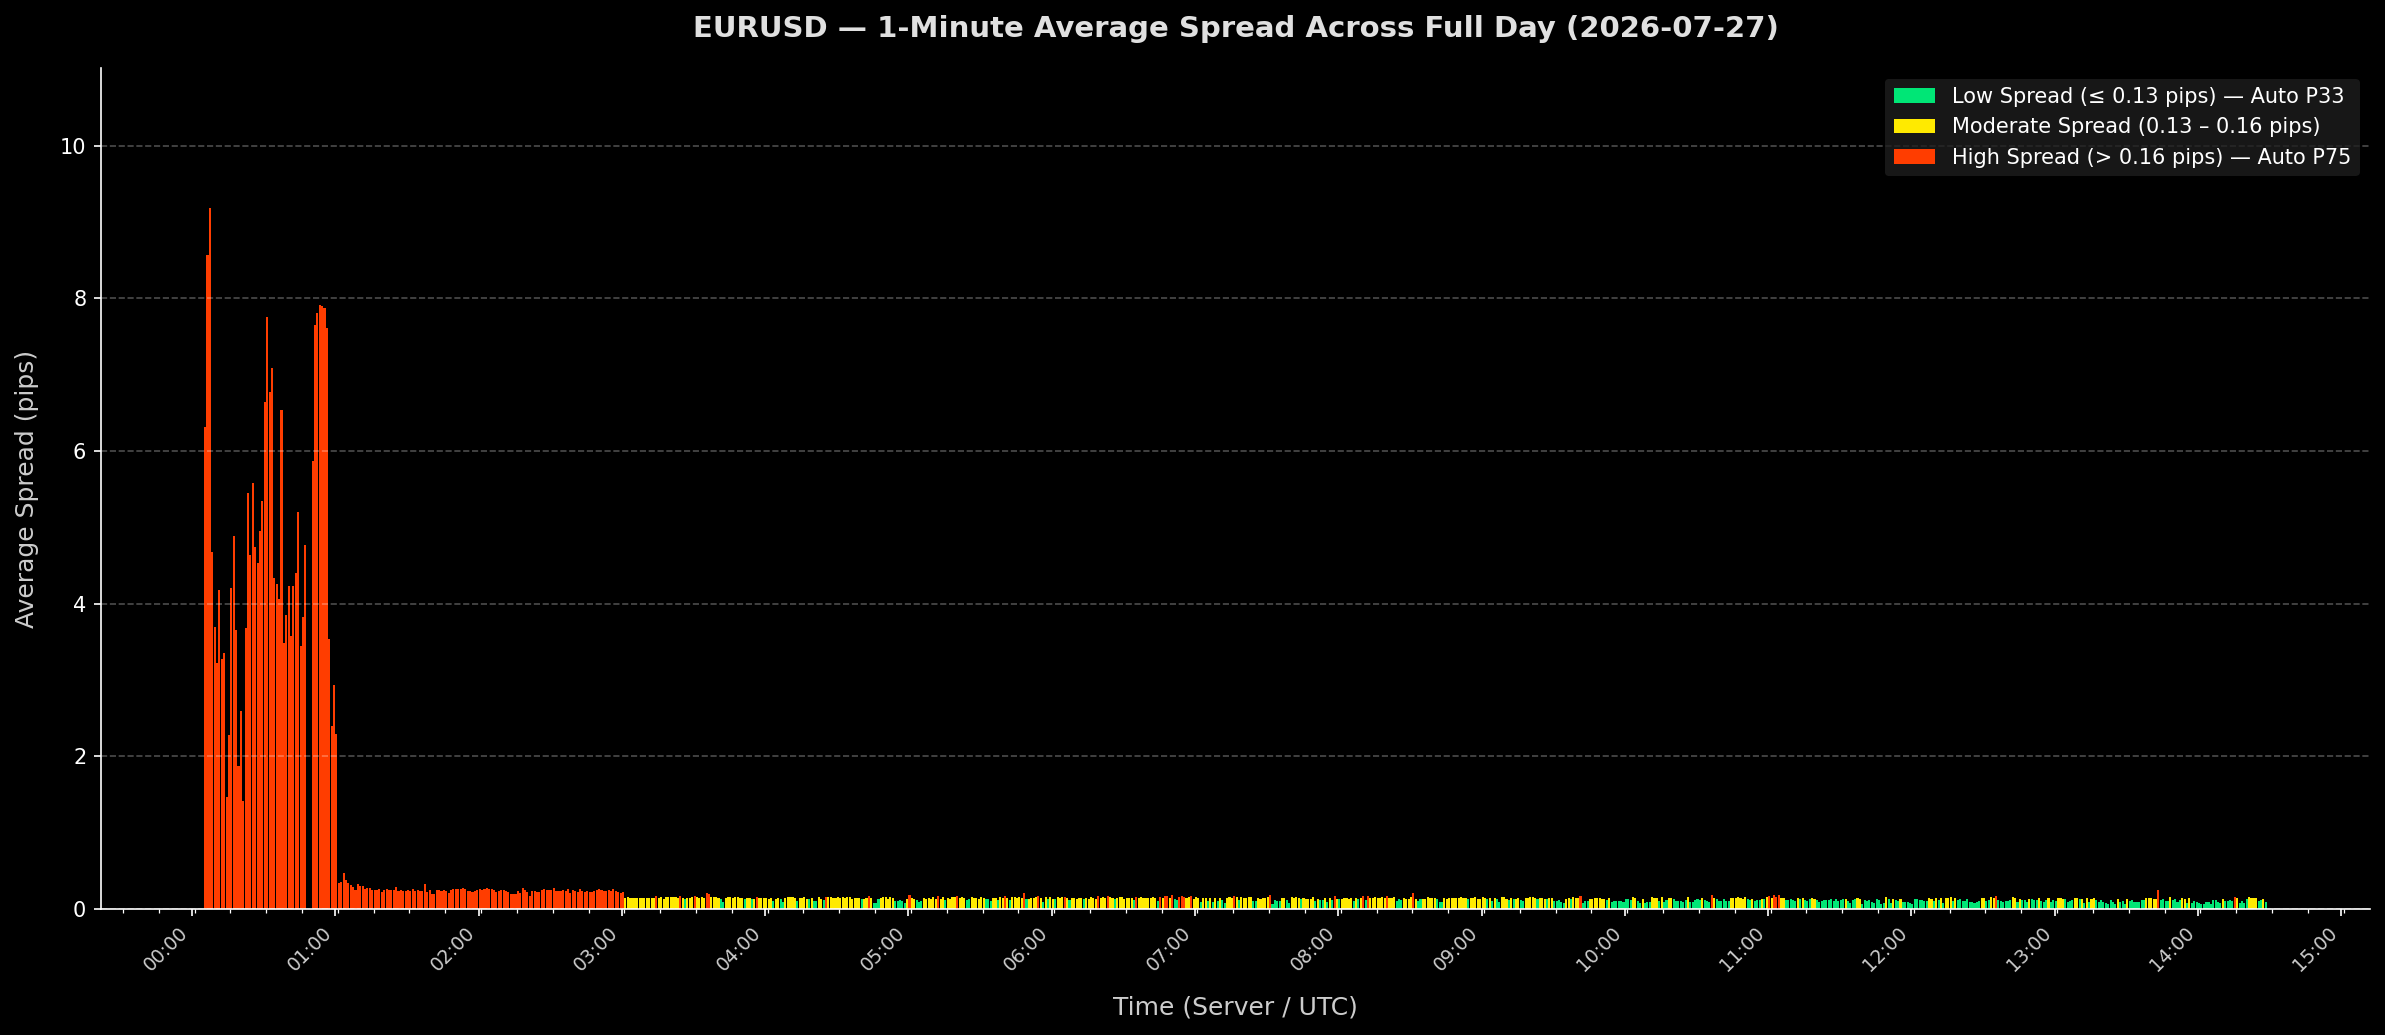

In [8]:
target_day = date(2026,7,27)

plot_spread_chart('EURUSD', target_day)

Fetching tick history for GBPUSD from 2026-07-27 00:00:00 to 2026-07-27 23:59:59...
✓ Processed 34,311 ticks into 861 1-minute spread bars (Unit: pips).
✓ Thresholds for GBPUSD: Low (≤ 0.20 pips) | High (> 0.24 pips)


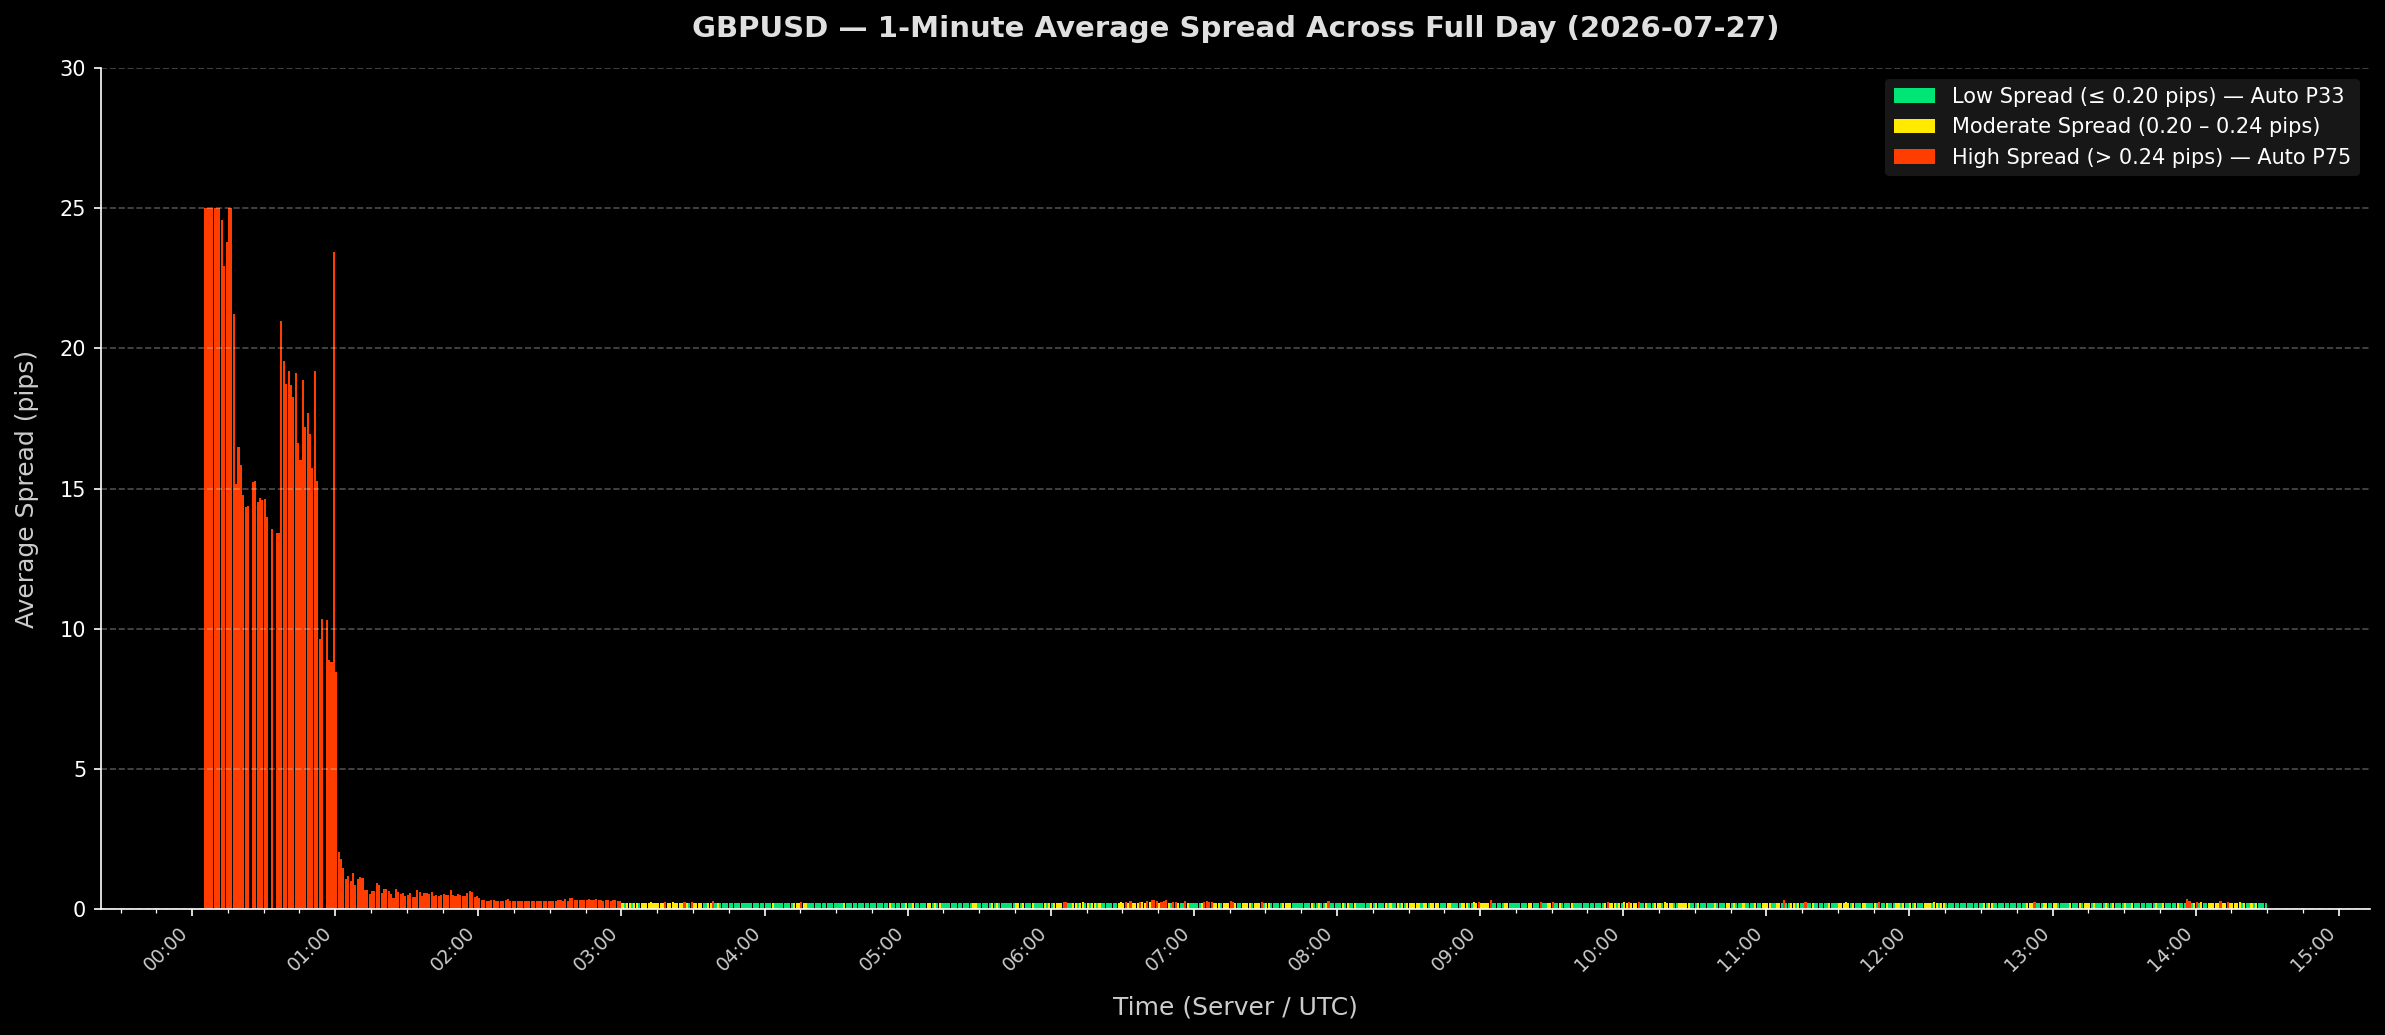

In [11]:
plot_spread_chart('GBPUSD', target_day)

Fetching tick history for XAUUSD from 2026-07-27 00:00:00 to 2026-07-27 23:59:59...
✓ Processed 239,976 ticks into 810 1-minute spread bars (Unit: cents).
✓ Thresholds for XAUUSD: Low (≤ 6.70 cents) | High (> 8.32 cents)


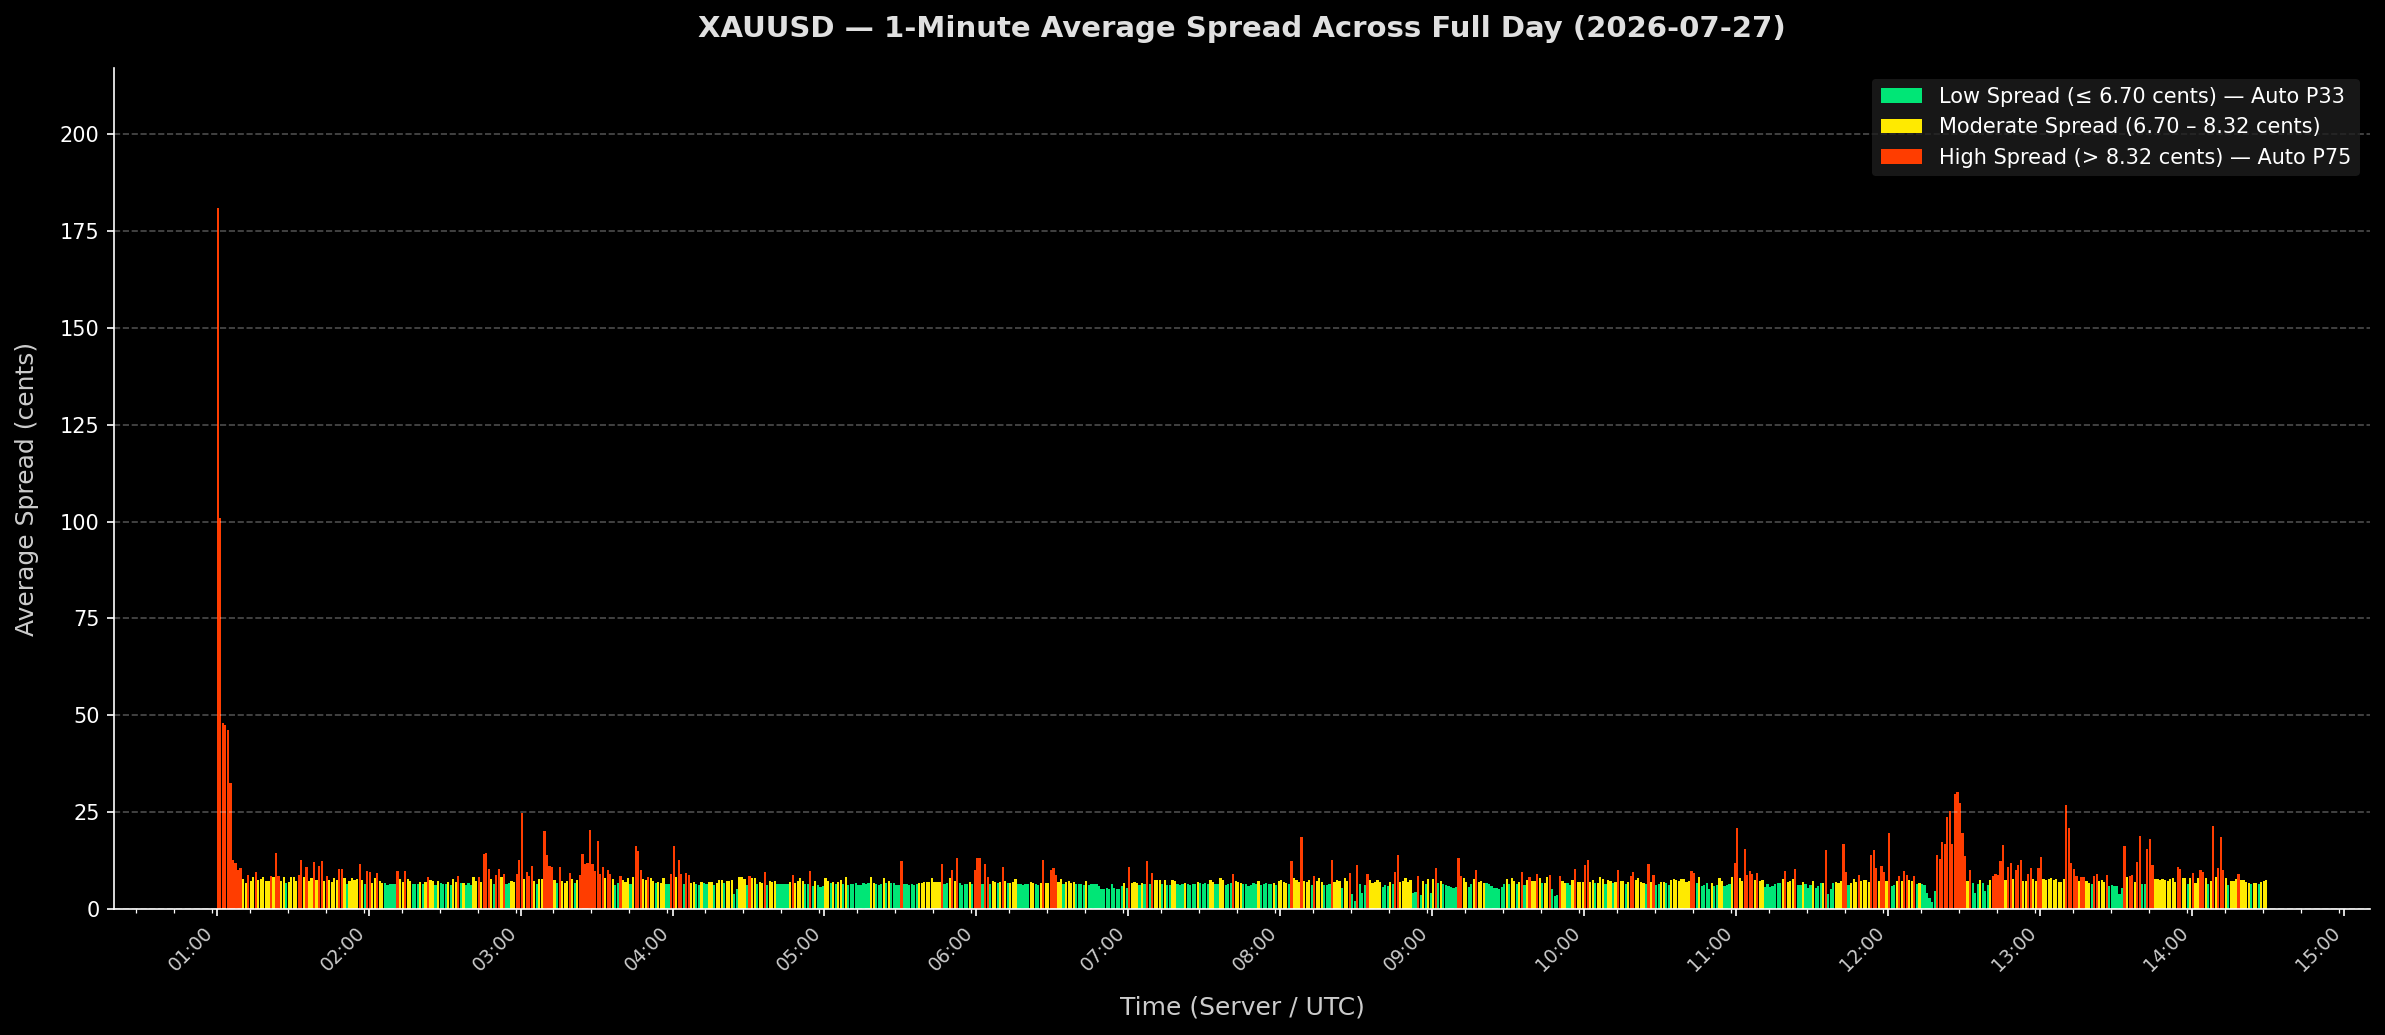

In [12]:
plot_spread_chart('XAUUSD', target_day)

## Multi-Asset Spread Analysis Summary

### 1. EURUSD (Forex Major)
* **Unit**: Measured in **Pips** (`1 pip = 10 points`).
* **Low Spread (P33)**: Compresses to **≤ 0.12 pips** during active London/NY overlap.
* **High Spread (P75)**: Expands to **> 0.15 pips** (up to 7.6 pips spike during Asian transition / market rollover).

### 2. WTI Crude Oil & XAUUSD Gold
* **Unit**: Measured in **Cents** ($0.01 per point).
* **Liquidity Dynamics**: Session-based spread compression during US Pit / European hours and expansion during interbank rollover.
